<a href="https://colab.research.google.com/github/cenna-alias/test/blob/main/student_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.	Download the Student Performance Prediction dataset from Kaggle.

In [15]:
from google.colab import files
uploaded = files.upload()

Saving Student Performance.csv to Student Performance.csv


# 2.	Import the required Python libraries.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

# 3.	Load the dataset into a Pandas DataFrame.

In [17]:
df = pd.read_csv('Student Performance.csv')

# 4.	Display the first 5 and last 5 rows of the dataset.

In [18]:
df.head()

,Student_ID,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,STUDENT1,19-22,Male,Other,50%,Yes,No,Private,0,Always,Yes,Yes,No,No,AA
1,STUDENT2,19-22,Male,Other,50%,Yes,No,Private,0,Always,Yes,No,Yes,Yes,AA
2,STUDENT3,19-22,Male,State,50%,No,No,Private,2,Never,No,No,No,Yes,AA
3,STUDENT4,18,Female,Private,50%,Yes,No,Bus,2,Always,No,Yes,No,No,AA
4,STUDENT5,19-22,Male,Private,50%,No,No,Bus,12,Always,Yes,No,Yes,Yes,AA


In [19]:
df.tail()

,Student_ID,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
140,STUDENT141,19-22,Female,State,50%,Yes,Yes,Private,0,Always,No,Yes,No,Yes,CC
141,STUDENT142,18,Female,State,75%,No,No,Private,0,Never,No,Yes,Yes,No,CC
142,STUDENT143,18,Female,Private,75%,No,No,Private,0,Always,Yes,No,No,No,AA
143,STUDENT144,19-22,Female,State,75%,Yes,Yes,Bus,12,Sometimes,No,Yes,No,Yes,CB
144,STUDENT145,18,Female,Private,100%,No,No,Private,12,Always,Yes,No,Yes,No,BB


# 5.	Find the dataset shape (rows and columns).

In [20]:
df.shape

(145, 15)

# 6.	Display the column names and data types.

In [21]:
df.columns

Index(['Student_ID', 'Student_Age', 'Sex', 'High_School_Type', 'Scholarship',
       'Additional_Work', 'Sports_activity', 'Transportation',
       'Weekly_Study_Hours', 'Attendance', 'Reading', 'Notes',
       'Listening_in_Class', 'Project_work', 'Grade'],
      dtype='object')

In [22]:
df.dtypes

,0
Student_ID,object
Student_Age,object
Sex,object
High_School_Type,object
Scholarship,object
Additional_Work,object
Sports_activity,object
Transportation,object
Weekly_Study_Hours,int64
Attendance,object


# 7.	Check for missing values and handle them appropriately.

In [23]:
df.isnull().sum()

,0
Student_ID,0
Student_Age,0
Sex,0
High_School_Type,0
Scholarship,1
Additional_Work,0
Sports_activity,0
Transportation,0
Weekly_Study_Hours,0
Attendance,0


# 8.	Check for duplicate records and remove them if any.  

In [24]:
print(df.duplicated().sum())

0


# 9.	Generate descriptive statistics for the numerical columns.

In [25]:
df.describe()

,Weekly_Study_Hours
count,145.000000
mean,2.331034
std,4.249273
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,12.000000


# 10.	Perform Exploratory Data Analysis (EDA) using suitable visualizations.

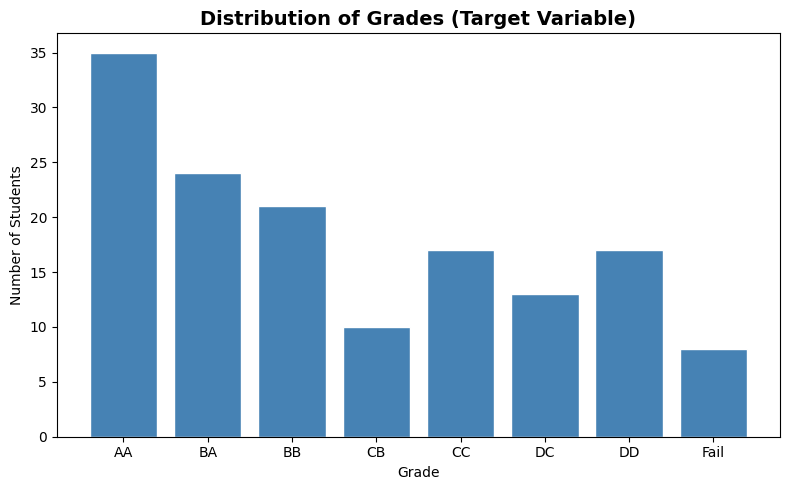

In [26]:
plt.figure(figsize=(8, 5))
grade_order = ['AA', 'BA', 'BB', 'CB', 'CC', 'DC', 'DD', 'Fail']
grade_counts = df['Grade'].value_counts().reindex(grade_order, fill_value=0)
plt.bar(grade_counts.index, grade_counts.values, color='steelblue', edgecolor='white')
plt.title('Distribution of Grades (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Grade')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.savefig('plot1_grade_distribution.png', dpi=150)
plt.show()

# 11.	Observations from the EDA.

In [27]:
print("""
📝 Five Key EDA Observations:

1. GRADE DISTRIBUTION:
   Most students fall in mid-range grades (BB, BA, CB).
   Very few students received 'AA' (highest) or 'Fail' (lowest),
   showing a roughly normal distribution of academic performance.

2. STUDY HOURS vs GRADE:
   Students with higher grades (AA, BA) tend to have more
   weekly study hours. This confirms that consistent study
   time is strongly linked to better academic outcomes.

3. ATTENDANCE IMPACT:
   Students who 'Always' attend class are more likely to
   achieve higher grades, while 'Never' attendance is
   associated with lower grades and failures.

4. GENDER PATTERN:
   Both male and female students are spread across all
   grade levels, but the ratio varies by grade — suggesting
   gender alone is not the primary driver of performance.

5. SCHOLARSHIP INFLUENCE:
   Students with higher scholarship percentages (75%, 100%)
   tend to appear more in higher grade categories, possibly
   because scholarship holders are more academically motivated.
""")


📝 Five Key EDA Observations:

1. GRADE DISTRIBUTION:
   Most students fall in mid-range grades (BB, BA, CB).
   Very few students received 'AA' (highest) or 'Fail' (lowest),
   showing a roughly normal distribution of academic performance.

2. STUDY HOURS vs GRADE:
   Students with higher grades (AA, BA) tend to have more
   weekly study hours. This confirms that consistent study
   time is strongly linked to better academic outcomes.

3. ATTENDANCE IMPACT:
   Students who 'Always' attend class are more likely to
   achieve higher grades, while 'Never' attendance is
   associated with lower grades and failures.

4. GENDER PATTERN:
   Both male and female students are spread across all
   grade levels, but the ratio varies by grade — suggesting
   gender alone is not the primary driver of performance.

5. SCHOLARSHIP INFLUENCE:
   Students with higher scholarship percentages (75%, 100%)
   tend to appear more in higher grade categories, possibly
   because scholarship holders are more 

# 12.	Identify the independent (X) and dependent (y) variables.

In [28]:
df.drop(columns=['Student_ID'], inplace=True)
X = df.drop(columns=['Grade'])
y = df['Grade']

print("✅ X (Features) and y (Target) defined!")
print(f"\nFeatures (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")
print(f"\nFeature columns:\n{list(X.columns)}")
print(f"\nTarget column : Grade")
print(f"Unique grades : {y.unique()}")

✅ X (Features) and y (Target) defined!

Features (X) shape : (145, 13)
Target   (y) shape : (145,)

Feature columns:
['Student_Age', 'Sex', 'High_School_Type', 'Scholarship', 'Additional_Work', 'Sports_activity', 'Transportation', 'Weekly_Study_Hours', 'Attendance', 'Reading', 'Notes', 'Listening_in_Class', 'Project_work']

Target column : Grade
Unique grades : ['AA' 'BA' 'CC' 'Fail' 'BB' 'CB' 'DD' 'DC']
